In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import pandas as pd
from src.data_loader import load_train_reviews
from src.data.split import create_train_validation_split, class_distribution

In [3]:
train_df = load_train_reviews()

train_df.shape

d:\Quera\Exercises\amazon-review-sentiment-analysis\src\data_loader.py:17: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


(838944, 11)

In [4]:
train_df.head()

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600


In [5]:
train_df["overall"].value_counts().sort_index()

overall
1     82950
2     56756
3     81239
4    156514
5    461485
Name: count, dtype: int64

In [7]:
class_distribution(train_df)

overall
1     9.89
2     6.77
3     9.68
4    18.66
5    55.01
Name: proportion, dtype: float64

In [8]:
train_split, valid_split = create_train_validation_split(train_df)

In [9]:
print(train_split.shape)
print(valid_split.shape)

(671155, 11)
(167789, 11)


In [10]:
comparison = pd.DataFrame(
    {
        "Original": class_distribution(train_df),
        "Train": class_distribution(train_split),
        "Validation": class_distribution(valid_split),
    }
)
comparison

,Original,Train,Validation
overall,,,
1,9.89,9.89,9.89
2,6.77,6.77,6.77
3,9.68,9.68,9.68
4,18.66,18.66,18.66
5,55.01,55.01,55.01


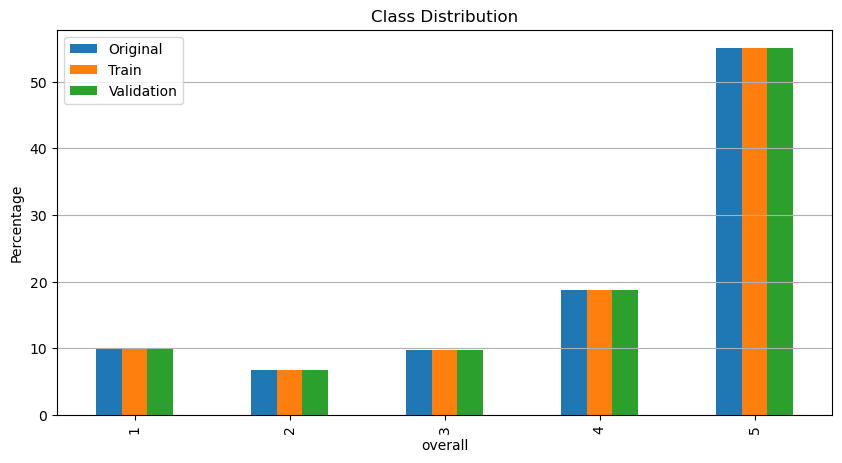

In [11]:
import matplotlib.pyplot as plt

comparison.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.ylabel("Percentage")

plt.title("Class Distribution")

plt.grid(axis="y")

plt.show()

In [12]:
comparison["Train Diff"] = comparison["Train"] - comparison["Original"]
comparison["Validation Diff"] = comparison["Validation"] - comparison["Original"]
comparison

,Original,Train,Validation,Train Diff,Validation Diff
overall,,,,,
1,9.89,9.89,9.89,0.0,0.0
2,6.77,6.77,6.77,0.0,0.0
3,9.68,9.68,9.68,0.0,0.0
4,18.66,18.66,18.66,0.0,0.0
5,55.01,55.01,55.01,0.0,0.0


In [ ]:
from pathlib import Path

output = Path("../data/interim")

output.mkdir(
    parents=True,
    exist_ok=True,
)

train_split.to_csv(
    output / "train_split.csv",
    index=False,
)

valid_split.to_csv(
    output / "valid_split.csv",
    index=False,
)

In [ ]:
comparison.describe()

In [ ]:
max_train_diff = comparison["Train Diff"].abs().max()
max_valid_diff = comparison["Validation Diff"].abs().max()

print(f"Max Train Difference: {max_train_diff:.3f}%")
print(f"Max Validation Difference: {max_valid_diff:.3f}%")

The class distribution is successfully preserved after the stratified split.